In [1]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

In [2]:
# 1. DEFINE THE SYSTEM DYNAMICS
N_sim = 7000 # Number of samples for closed-loop testing
N_train = 3000
dt = 1e-3

# Plant: 2nd Order Underdamped System
wn = 2 * np.pi * 50
zeta = 0.5
sys_cont = signal.TransferFunction([wn**2], [1, 2*zeta*wn, wn**2])
sys_disc = sys_cont.to_discrete(dt, method='zoh')
A_p, B_p, C_p, D_p = signal.tf2ss(sys_disc.num, sys_disc.den)
nx = A_p.shape[0] # Number of plant states

# Turbulence: First-order AR model (random walk)
# d[k+1] = a_d * d[k] + w[k]
a_d = 0.97
A_d = np.array([[2.61,-2.45,1.05,-0.22],
                [1,0,0,0],
                [0,1,0,0],
                [0,0,1,0]])*a_d
nxd = A_d.shape[1]

/home/mmenessini/.local/lib/python3.11/site-packages/scipy/signal/_filter_design.py:1746: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


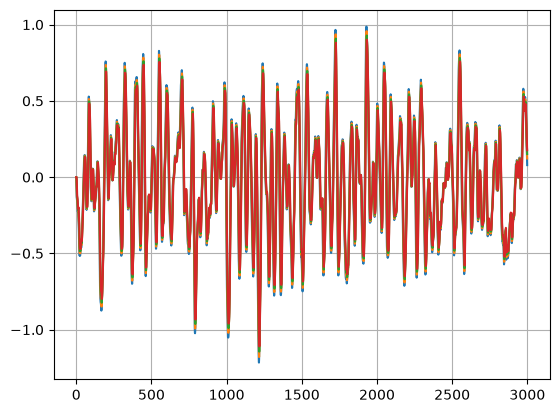

In [3]:
# 2. GENERATE OPEN-LOOP TRAINING DATA
np.random.seed(42)

# Input excitation: Band-limited white noise
u_train = np.random.randn(N_train) * 2.0 

# Simulate Plant & Turbulence
y_train = np.zeros(N_train)
x_state = np.zeros((nx, 1))
turb_state = np.zeros((nxd,1))
# turb_state = np.random.randn(nxd).reshape([nxd,1]) * 0.01

vec = np.zeros([nxd,N_train])

for k in range(N_train):
    # Update plant state
    y_plant = (C_p @ x_state)[0, 0] + D_p[0, 0] * u_train[k]
    x_state = A_p @ x_state + B_p * u_train[k]
    
    # Update turbulence state
    turb_state = A_d @ turb_state 
    turb_state[0,0] += np.random.randn() * 0.01
    vec[:,k] = turb_state[:,0]
    
    # Combined measurement
    y_train[k] = y_plant + turb_state[0,0]


plt.figure()
plt.plot(vec.T)
plt.grid()

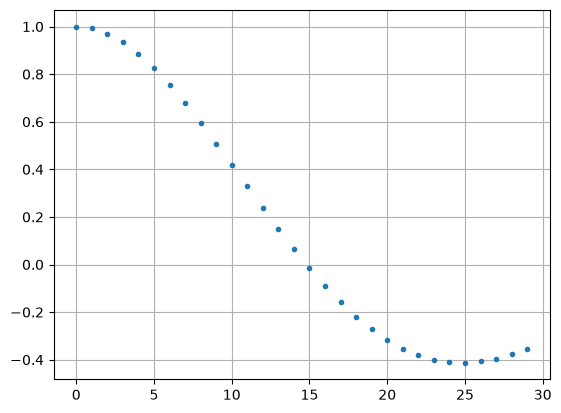

In [4]:
def get_autocov(vec,k:int):
    if k == 0:
        return np.mean(vec*vec)
    else:
        return np.mean(vec[k:]*vec[:-k])

N = 30
autocovs = np.zeros(N)

for i in range(N):
    autocovs[i] = get_autocov(vec[0,:],i)

autocorrs = autocovs/autocovs[0]

plt.figure()
plt.plot(autocorrs,'.')
plt.grid()

In [5]:
order = 4

dec = 1

rho = autocorrs[::dec]
rho_vec = rho[1:5]
Rmat = np.array([[rho[0],rho[1],rho[2],rho[3]],
                 [rho[1],rho[0],rho[1],rho[2]],
                 [rho[2],rho[1],rho[0],rho[1]],
                 [rho[3],rho[2],rho[1],rho[0]]])

phi = np.linalg.inv(Rmat) @ rho_vec
print(phi,np.sum(phi),A_d[0,:],np.sum(A_d[0,:]))

[ 2.34712807 -0.65000064 -1.81096136  1.12155803] 1.0077240947132395 [ 2.5317 -2.3765  1.0185 -0.2134] 0.9602999999999997


In [6]:
# 3. BUILD HANKEL MATRICES & TRAIN DDSPC
N = 20 # Past horizon (must capture 2nd order dynamics + delays)
M = 10 # Future prediction horizon
K = N_train - N - M + 1 # Number of columns in Hankel matrices

Y_p = np.zeros((N, K))
U_p = np.zeros((N, K))
Y_f = np.zeros((M, K))
U_f = np.zeros((M, K))

for j in range(K):
    Y_p[:, j] = y_train[j : j+N]
    U_p[:, j] = u_train[j : j+N]
    Y_f[:, j] = y_train[j+N : j+N+M]
    U_f[:, j] = u_train[j+N : j+N+M]

# Past data matrix W_p = [Y_p; U_p]
W_p = np.vstack((Y_p, U_p))

# Predictor equation: Y_f = L_w * W_p + L_u * U_f
# Solve via Least Squares (Projection): [L_w, L_u] = Y_f * pinv([W_p; U_f])
Data_Matrix = np.vstack((W_p, U_f))
Theta = Y_f @ np.linalg.pinv(Data_Matrix)

# Extract Predictor Matrices
L_w = Theta[:, :2*N]
L_u = Theta[:, 2*N:]

# Pre-compute control gain to speed up real-time loop
# J = ||Y_f||^2 + lambda * ||U_f||^2
# U_f = -(L_u^T * L_u + lambda * I)^-1 * L_u^T * L_w * W_p
lambda_penalty = 1e-3
H_inv = np.linalg.inv(L_u.T @ L_u + lambda_penalty * np.eye(M))
K_ctrl = -H_inv @ L_u.T @ L_w



In [7]:

# 4. CLOSED-LOOP SIMULATION (RECEDING HORIZON)

# Arrays to store closed-loop vs open-loop performance
y_cl = np.zeros(N_sim)
u_cl = np.zeros(N_sim)
y_ol = np.zeros(N_sim) # What turbulence would do with no control

delay = 2
y_cl_int = np.zeros(N_sim)

# Initialize histories with zeros
y_hist = np.zeros(N).tolist()
u_hist = np.zeros(N).tolist()

x_state = np.zeros((nx, 1))
turb_state = 0.0

u_int = 0
gain = 0.7

for k in range(N_sim):
    # 1. Update Disturbance (Turbulence)
    turb_noise = np.random.randn() * 0.5
    turb_state = a_d * turb_state + turb_noise
    y_ol[k] = turb_state # Open-loop baseline
    
    # 2. Construct current past-data vector w_p
    w_p = np.concatenate((y_hist[-N:], u_hist[-N:]))
    
    # 3. Compute DDSPC Optimal Control (Receding Horizon)
    U_opt = K_ctrl @ w_p
    u_curr = U_opt[0] # Apply only the first move
    u_cl[k] = u_curr
    
    # 4. Step the physical plant
    y_plant = (C_p @ x_state)[0, 0] + D_p[0, 0] * u_curr
    x_state = A_p @ x_state + B_p * u_curr

    # Simple integrator
    if k > delay:
        u_int -= gain * y_cl_int[k-delay]
        y_int = (C_p @ x_state)[0, 0] + D_p[0, 0] * u_int
        y_cl_int[k] = y_int + turb_state
    else:
        y_cl_int[k] = turb_state
    
    
    # 5. Measure combined output and update history
    y_curr = y_plant + turb_state
    y_cl[k] = y_curr

    
    y_hist.append(y_curr)
    u_hist.append(u_curr)


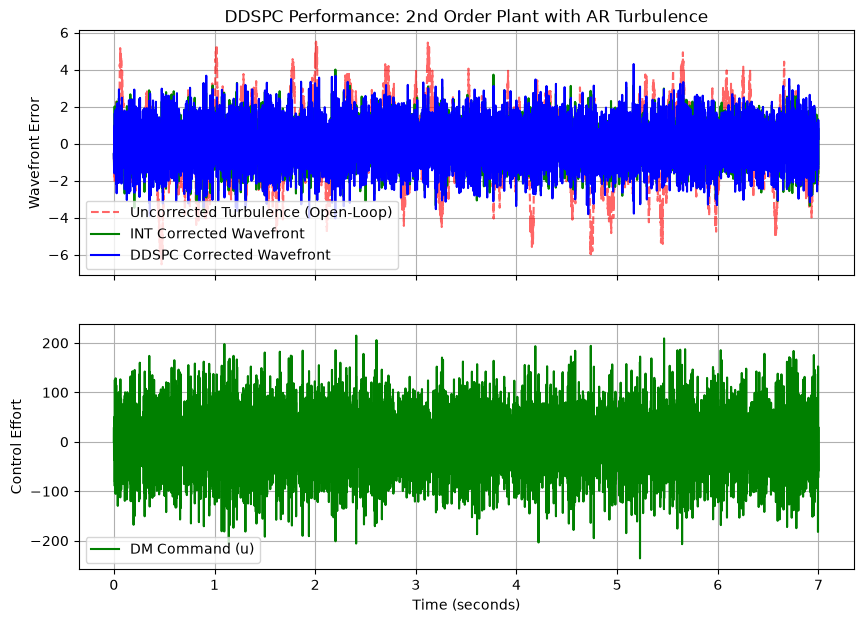

In [8]:
# 5. PLOTTING RESULTS
time_axis = np.arange(N_sim) * dt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(time_axis, y_ol, label="Uncorrected Turbulence (Open-Loop)", color='red', alpha=0.6, linestyle='--')
ax1.plot(time_axis, y_cl_int, label="INT Corrected Wavefront", color='green', linewidth=1.5)
ax1.plot(time_axis, y_cl, label="DDSPC Corrected Wavefront", color='blue', linewidth=1.5)
ax1.set_ylabel("Wavefront Error")
ax1.set_title("DDSPC Performance: 2nd Order Plant with AR Turbulence")
ax1.legend()
ax1.grid(True)

ax2.plot(time_axis, u_cl, label="DM Command (u)", color='green')
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Control Effort")
ax2.legend()
ax2.grid(True)
